In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Load data
file_path ="C:/Users/bhara/Downloads/netflix_titles.csv.zip"
df =pd.read_csv(file_path)

# Display first row
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
# Basic info
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
# Check duplicate
df.duplicated().value_counts()

False    8807
Name: count, dtype: int64

In [5]:
# checking missing value
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [6]:
#plot missing value
missing =df.isnull().sum()

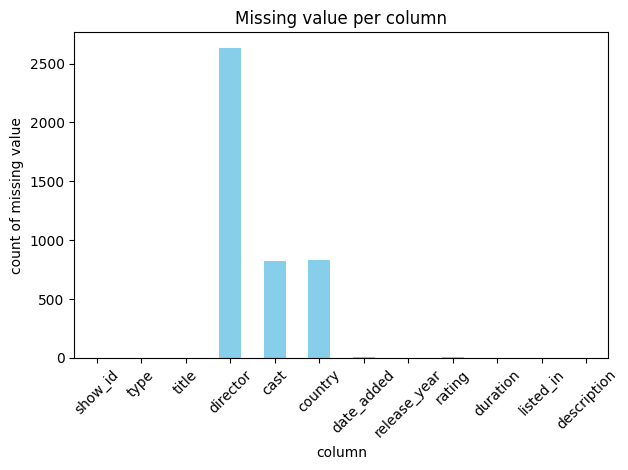

In [7]:
ax = missing.plot(kind ="bar",color = "skyblue")
plt.title("Missing value per column")
plt.ylabel("count of missing value")
plt.xlabel("column")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

# Drop missing date rows
df.dropna(subset=['date_added'], inplace=True)

In [9]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [10]:
# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'],errors='coerce')
df['year_added'] = df['date_added'].dt.year

In [11]:
#Extract duration number
df['duration_num'] = df['duration'].str.extract('(\\d+)').astype(float)

<function matplotlib.pyplot.show(close=None, block=None)>

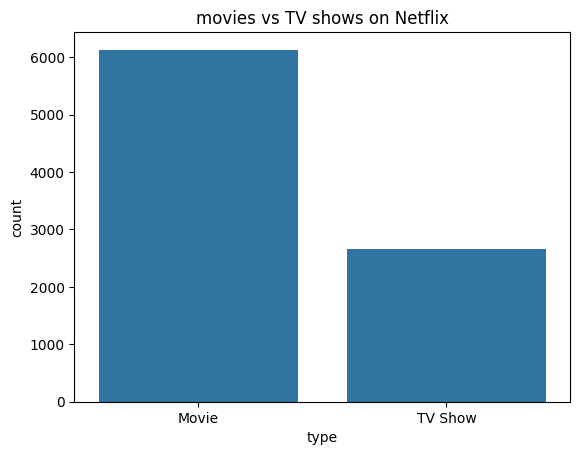

In [12]:
# Graph 1:Movies vs TV Shows
sns.countplot(x='type',data=df)
plt.title("movies vs TV shows on Netflix")
plt.show

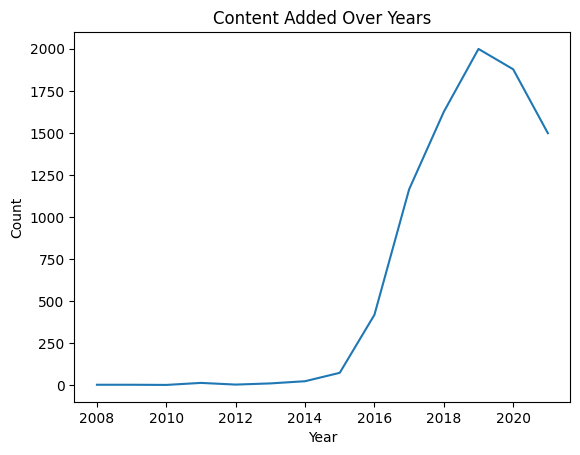

In [13]:
# Graph 2: Content over years
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

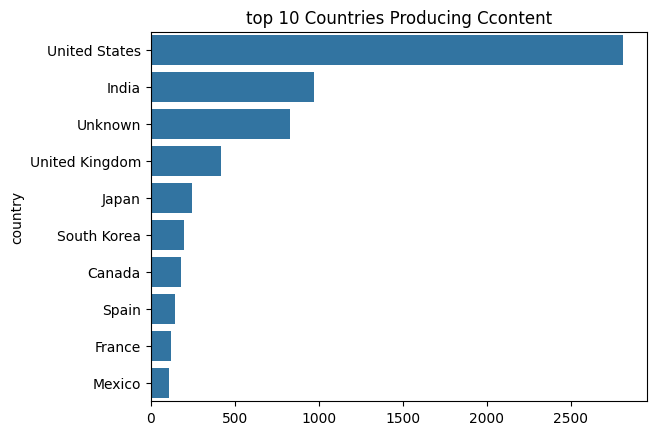

In [14]:
# Graph 3: Top countries
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values,y=top_countries.index)
plt.title("top 10 Countries Producing Ccontent")
plt.show()


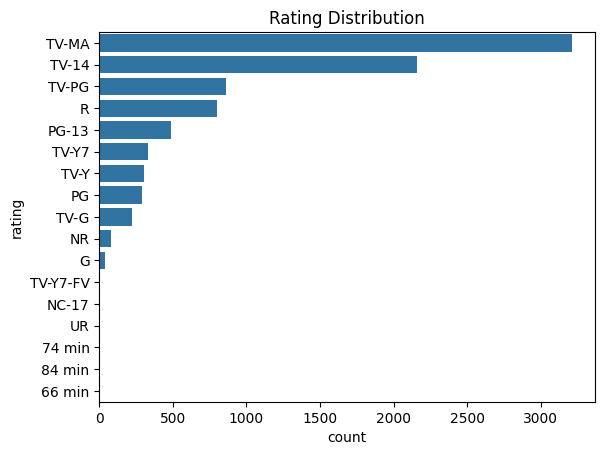

In [15]:
# Graph 4: Ratings
sns.countplot(y='rating',data=df,order=df['rating'].value_counts().index)
plt.title("Rating Distribution")
plt.show()

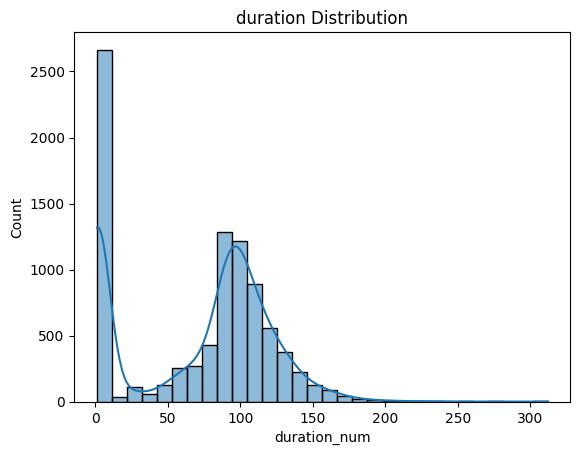

In [16]:
# Graph 5: Duration
sns.histplot(df['duration_num'],bins=30,kde=True)
plt.title("duration Distribution")
plt.show()

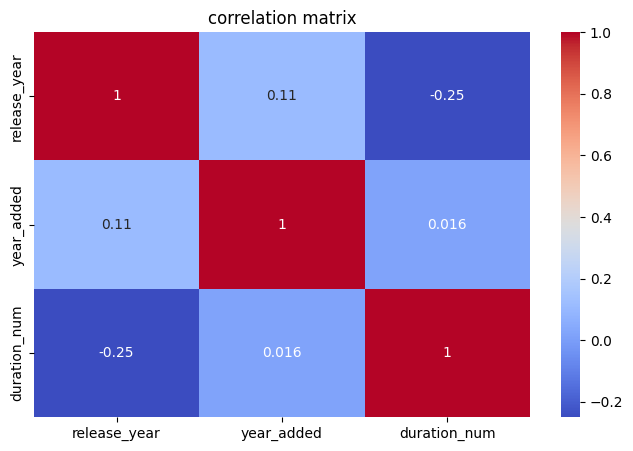

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("correlation matrix")
plt.show()

In [18]:
# 🔹 Final Conclusion

# - Netflix has more movies than TV shows.
# - Content increased rapidly after 2015.
# - USA and India produce the most content.
# - Most shows are for mature audiences (TV-MA, TV-14).
# - Movie duration is mostly between 80–120 minutes.
